# Attendance Analyzer


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Attendance Dataset

Upload/select `attendance_dataset_100_students.csv` in the same Jupyter folder as this notebook.

In [14]:
# Load the CSV dataset
file_path = "/home/teja-sai-reddy/Downloads/attendance_analysis_100_students.csv"
df = pd.read_csv(file_path)

print(f"Total students: {len(df)}")
df.head()

Total students: 100


,Student_ID,Student_Name,Classes_Conducted,Classes_Attended,Attendance_Percentage,Status
0,1,Student_001,45,41,91.11,Eligible
1,2,Student_002,50,38,76.00,Eligible
2,3,Student_003,35,20,57.14,Shortage
3,4,Student_004,45,33,73.33,Shortage
4,5,Student_005,45,27,60.00,Shortage


## 2. Check the Dataset

In [15]:
# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (100, 6)

Column names:
['Student_ID', 'Student_Name', 'Classes_Conducted', 'Classes_Attended', 'Attendance_Percentage', 'Status']

Missing values:
Student_ID               0
Student_Name             0
Classes_Conducted        0
Classes_Attended         0
Attendance_Percentage    0
Status                   0
dtype: int64


## 3. Calculate Attendance Percentage

In [16]:
# Calculate attendance percentage
df["Attendance_Percentage"] = (
    df["Classes_Attended"] / df["Classes_Conducted"] * 100
).round(2)

df.head(10)

,Student_ID,Student_Name,Classes_Conducted,Classes_Attended,Attendance_Percentage,Status
0,1,Student_001,45,41,91.11,Eligible
1,2,Student_002,50,38,76.00,Eligible
2,3,Student_003,35,20,57.14,Shortage
3,4,Student_004,45,33,73.33,Shortage
4,5,Student_005,45,27,60.00,Shortage
5,6,Student_006,50,40,80.00,Eligible
6,7,Student_007,35,34,97.14,Eligible
7,8,Student_008,35,33,94.29,Eligible
8,9,Student_009,45,31,68.89,Shortage
9,10,Student_010,40,35,87.50,Eligible


## 4. Attendance Status

In [17]:
# Students with at least 75% attendance are considered eligible
df["Status"] = df["Attendance_Percentage"].apply(
    lambda x: "Eligible" if x >= 75 else "Shortage"
)

df[["Student_ID", "Student_Name", "Attendance_Percentage", "Status"]].head(20)

,Student_ID,Student_Name,Attendance_Percentage,Status
0,1,Student_001,91.11,Eligible
1,2,Student_002,76.00,Eligible
2,3,Student_003,57.14,Shortage
3,4,Student_004,73.33,Shortage
4,5,Student_005,60.00,Shortage
5,6,Student_006,80.00,Eligible
6,7,Student_007,97.14,Eligible
7,8,Student_008,94.29,Eligible
8,9,Student_009,68.89,Shortage
9,10,Student_010,87.50,Eligible


## 5. Students Below 75%

In [18]:
below_75 = df[df["Attendance_Percentage"] < 75]

print(f"Students below 75% attendance: {len(below_75)}")
below_75[["Student_ID", "Student_Name", "Attendance_Percentage"]]

Students below 75% attendance: 52


,Student_ID,Student_Name,Attendance_Percentage
2,3,Student_003,57.14
3,4,Student_004,73.33
4,5,Student_005,60.00
8,9,Student_009,68.89
10,11,Student_011,68.89
19,20,Student_020,71.11
22,23,Student_023,55.00
23,24,Student_024,66.00
24,25,Student_025,70.00
25,26,Student_026,55.00


## 6. Students With 75% or More

In [19]:
above_75 = df[df["Attendance_Percentage"] >= 75]

print(f"Students with 75% or more attendance: {len(above_75)}")
above_75[["Student_ID", "Student_Name", "Attendance_Percentage"]]

Students with 75% or more attendance: 48


,Student_ID,Student_Name,Attendance_Percentage
0,1,Student_001,91.11
1,2,Student_002,76.00
5,6,Student_006,80.00
6,7,Student_007,97.14
7,8,Student_008,94.29
9,10,Student_010,87.50
11,12,Student_012,97.78
12,13,Student_013,86.67
13,14,Student_014,80.00
14,15,Student_015,88.00


## 7. Highest Attendance

In [20]:
highest = df.loc[df["Attendance_Percentage"].idxmax()]

print("Student with highest attendance:")
print("Name:", highest["Student_Name"])
print("Attendance:", highest["Attendance_Percentage"], "%")

Student with highest attendance:
Name: Student_018
Attendance: 100.0 %


## 8. Class Average Attendance

In [21]:
class_average = df["Attendance_Percentage"].mean().round(2)
print("Average class attendance:", class_average, "%")

Average class attendance: 74.93 %


## 9. Overall Attendance

In [10]:
total_conducted = df["Classes_Conducted"].sum()
total_attended = df["Classes_Attended"].sum()
overall_attendance = round(total_attended / total_conducted * 100, 2)

print("Total classes conducted across all students:", total_conducted)
print("Total classes attended across all students:", total_attended)
print("Overall attendance:", overall_attendance, "%")

Total classes conducted across all students: 4320
Total classes attended across all students: 3235
Overall attendance: 74.88 %


## 10. Attendance Summary

In [11]:
total_students = len(df)
eligible_students = len(df[df["Attendance_Percentage"] >= 75])
shortage_students = len(df[df["Attendance_Percentage"] < 75])

print("========== ATTENDANCE SUMMARY ==========")
print("Total students       :", total_students)
print("Eligible students    :", eligible_students)
print("Students with shortage:", shortage_students)
print("Class average        :", class_average, "%")
print("Overall attendance   :", overall_attendance, "%")

if shortage_students == total_students:
    print("Warning: All students are below 75% attendance.")
elif eligible_students == total_students:
    print("All students have sufficient attendance.")
else:
    print("Some students are below the required attendance.")

========== ATTENDANCE SUMMARY ==========
Total students       : 100
Eligible students    : 48
Students with shortage: 52
Class average        : 74.93 %
Overall attendance   : 74.88 %
Some students are below the required attendance.


## 11. Attendance Distribution

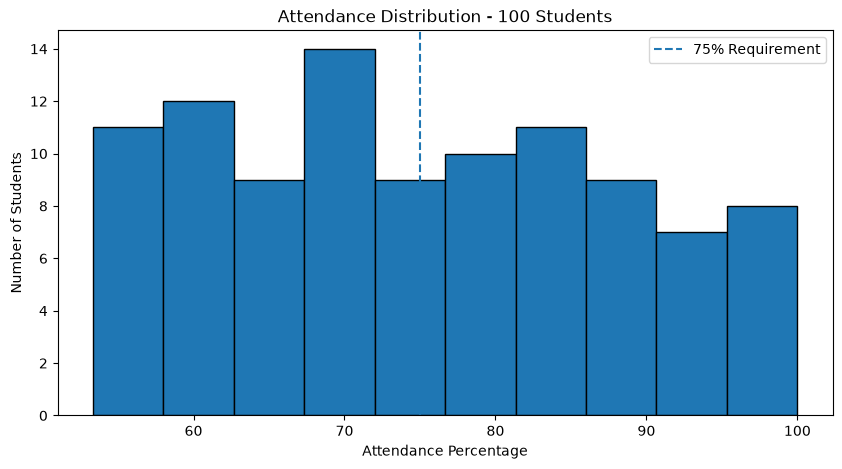

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(df["Attendance_Percentage"], bins=10, edgecolor="black")
plt.axvline(75, linestyle="--", label="75% Requirement")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")
plt.title("Attendance Distribution - 100 Students")
plt.legend()
plt.show()

## 12. Save the Analyzed Dataset

In [13]:
# Save the processed attendance data
output_file = "attendance_analysis_100_students.csv"
df.to_csv(output_file, index=False)
print(f"Saved analyzed dataset as: {output_file}")

Saved analyzed dataset as: attendance_analysis_100_students.csv
